In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [72]:
data = pd.read_parquet("data/flights_economy_1gb")

In [73]:
data.columns

Index(['legId', 'searchDate', 'flightDate', 'startingAirport',
       'destinationAirport', 'numDaysToFlight', 'numLayovers',
       'layoverDurationMinutes', 'seatsRemaining', 'travelDuration',
       'totalTravelDistance', 'elapsedDays', 'isBasicEconomy', 'isRefundable',
       'isNonStop', 'baseFare', 'totalFare', 'segmentsDepartureTime',
       'segmentsArrivalTime', 'segmentsArrivalAirportCode',
       'segmentsDepartureAirportCode', 'segmentsAirlineName',
       'segmentsAirlineCode', 'segmentsAircraft', 'segmentsDurationInMinutes',
       'segmentsDistance', 'segmentsCabinCode'],
      dtype='str')

## Outlier Detection and Cleaning

In [75]:
# 1. Convert the string column to a Pandas datetime object
data['flightDate'] = pd.to_datetime(data['flightDate'])

# 2. Get the name of the day (e.g., 'Monday', 'Tuesday', etc.)
# Great for charts and reading
data['flightDayName'] = data['flightDate'].dt.day_name()

# 3. Get the numeric day of the week (0 = Monday, 6 = Sunday)
# Great for regression models or numeric sorting
data['flightDayNum'] = data['flightDate'].dt.dayofweek

# Let's check the first few rows to verify
print(data[['flightDate', 'flightDayName', 'flightDayNum']].head())

# 1. Pre-process the strict airline rule ONCE for the whole dataset
# This replaces the need to check lambda x inside a loop 580,000 times.
def get_strict_airline(segments):
    if len(segments) > 0 and all(a == segments[0] for a in segments):
        return segments[0]
    return None

data['strict_al_code'] = data['segmentsAirlineCode'].apply(get_strict_airline)

  flightDate flightDayName  flightDayNum
0 2022-05-14      Saturday             5
1 2022-08-15        Monday             0
2 2022-07-11        Monday             0
3 2022-07-16      Saturday             5
4 2022-07-09      Saturday             5


In [76]:
# 1. CLEAN THE DATA FIRST
# Filter out the 'Refundable' outliers which are likely skewed
# and filter out 'Basic Economy' if you want a clean 'Standard Economy' comparison
df_clean = data[data['isRefundable'] == 0].copy()

# 2. ADD TRAVEL DURATION (Isolate the 'Time' factor)
df_clean['travelDuration'] = pd.to_numeric(df_clean['travelDuration'], errors='coerce')

In [77]:
# You will need to install the library first: pip install isotree
from isotree import IsolationForest

# 1. Define the features that contextualize the price
features = ['totalFare', 'travelDuration', 'numDaysToFlight']

# Drop NaNs from the subset we are modeling
df_model = df_clean.dropna(subset=features).copy()

# 2. Initialize the Extended Isolation Forest
# The magic parameter is 'ndim'. 
# ndim=1 is standard axis-parallel IForest. 
# ndim=2 (or higher) enables the Extended sloped hyperplanes.
eif_model = IsolationForest(ndim=2, ntrees=100, random_seed=42)

print("Fitting Extended Isolation Forest... (Slicing with sloped hyperplanes)")

# 3. Fit and predict anomaly scores
# Unlike scikit-learn, isotree returns a continuous anomaly score from 0 to 1.
# Scores closer to 1 are extreme anomalies.
df_model['anomaly_score'] = eif_model.fit_predict(df_model[features])

# 4. Set a dynamic threshold (e.g., dropping the top 2% most anomalous scores)
threshold = df_model['anomaly_score'].quantile(0.98)

# Filter out the anomalies (keeping only scores below the threshold)
df_pruned_eif = df_model[df_model['anomaly_score'] < threshold].copy()

# Clean up the dataframe
df_final = df_pruned_eif.drop(columns=['anomaly_score'])

print(f"Threshold set at anomaly score: {threshold:.4f}")
print(f"Removed {len(df_model) - len(df_pruned_eif)} contextual outliers using EIF.")

Fitting Extended Isolation Forest... (Slicing with sloped hyperplanes)


/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/isotree/__init__.py:1737: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  X_cat = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"])
/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/isotree/__init__.py:1757: UserWarning: Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.
  self.cols_categ_    = X.select_dtypes(include = [pd.CategoricalDtype, "object", "bool"]).columns.to_numpy(copy=True)


Threshold set at anomaly score: 0.4830
Removed 16427 contextual outliers using EIF.


## Hypothesis Testing

### Hypothesis 1: The Non-Stop Premium
This test focuses on whether the convenience of a non-stop flight significantly increases the price within the same airline and route.

* **Null Hypothesis ($H_0$):** There is no statistically significant difference between the mean price of non-stop flights and indirect flights on the same route for a given airline.
    * $$\mu_{\text{non-stop}} = \mu_{\text{indirect}}$$
* **Alternative Hypothesis ($H_1$):** Non-stop flights command a statistically significant price premium over indirect flights on the same route for a given airline.
    * $$\mu_{\text{non-stop}} > \mu_{\text{indirect}}$$


In [78]:
from scipy import stats
import numpy as np

# Drop any rows where flights mix airlines (strict_al_code is None)
df_test = df_final.dropna(subset=['strict_al_code']).copy()

# 2. Define the columns that make up a "Scenario"
group_cols = [
    'startingAirport', 
    'destinationAirport', 
    'isBasicEconomy', 
    'isRefundable', 
    'strict_al_code'
]

print("Grouping data... (This takes a few seconds)")
# 3. Group by all criteria PLUS isNonStop, and gather the fares into lists
# .unstack() pivots the data so isNonStop True and False become side-by-side columns
grouped_fares = df_test.groupby(group_cols + ['isNonStop'])['totalFare'].apply(list).unstack(fill_value=[])

# Ensure both True and False columns exist just in case
if True not in grouped_fares.columns: grouped_fares[True] = [[] for _ in range(len(grouped_fares))]
if False not in grouped_fares.columns: grouped_fares[False] = [[] for _ in range(len(grouped_fares))]

# 4. Iterate ONLY through the combinations that actually exist
print("Running hypothesis tests on valid scenarios...")
results_list = []

for idx, row in grouped_fares.iterrows():
    direct_fares = row[True]
    indirect_fares = row[False]
    
    # Only test scenarios where both sides have 30+ flights
    if len(direct_fares) >= 30 and len(indirect_fares) >= 30:
        t_stat, p_value = stats.ttest_ind(direct_fares, indirect_fares, equal_var=False)
        
        # Checking if p-value is significant AND direct is actually more expensive
        is_significant = (p_value < 0.05) and (np.mean(direct_fares) > np.mean(indirect_fares))
        
        # UPDATED APPEND BLOCK: idx now exactly matches the 5 group_cols
        results_list.append({
            "startingAirport": idx[0],
            "destinationAirport": idx[1],
            "isBasicEco": idx[2],
            "isRefundable": idx[3],
            "airlineCode": idx[4],
            "isSignificantlyExpensive": is_significant,
            "directSample_N": len(direct_fares),
            "indirectSample_N": len(indirect_fares)
        })

# 5. Build the final dataframe instantly
results = pd.DataFrame(results_list)
print(f"Finished! Found {len(results)} valid scenarios with enough data to test.")

Grouping data... (This takes a few seconds)
Running hypothesis tests on valid scenarios...


/home/aryan-bodhe/Desktop/VSCode/IITH/Business Python/env/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


Finished! Found 585 valid scenarios with enough data to test.


In [79]:
# Count how many scenarios proved your hypothesis
summary = results['isSignificantlyExpensive'].value_counts(normalize=True) * 100
print("Percentage of scenarios where Non-Stop is significantly more expensive:")
print(summary)

# See which airlines charge the premium most often
premium_by_airline = results.groupby('airlineCode')['isSignificantlyExpensive'].mean() * 100
print("\nPercentage of routes with a non-stop premium, by Airline:")
print(premium_by_airline.sort_values(ascending=False))

# View the first 5 routes where the premium is real
print("\nExamples of routes charging a premium:")
print(results[results['isSignificantlyExpensive'] == True][["startingAirport","destinationAirport", "airlineCode"]])
# results.columns

Percentage of scenarios where Non-Stop is significantly more expensive:
isSignificantlyExpensive
False    85.641026
True     14.358974
Name: proportion, dtype: float64

Percentage of routes with a non-stop premium, by Airline:
airlineCode
AA    25.120773
B6    23.636364
UA    11.949686
AS     0.000000
DL     0.000000
F9     0.000000
Name: isSignificantlyExpensive, dtype: float64

Examples of routes charging a premium:
    startingAirport destinationAirport airlineCode
21              ATL                LGA          AA
24              ATL                LGA          AA
28              ATL                ORD          AA
34              ATL                PHL          AA
47              BOS                DEN          B6
..              ...                ...         ...
562             SFO                EWR          UA
566             SFO                IAD          UA
570             SFO                JFK          B6
581             SFO                ORD          UA
582             S

In [80]:
# 3. RE-RUN REGRESSION WITH BETTER CONTROLS
import statsmodels.formula.api as smf

# Adding flightDayNum and travelDuration
formula = """
totalFare ~ isNonStop + travelDuration + numDaysToFlight + 
            isBasicEconomy + flightDayNum
"""

model_v2 = smf.ols(formula=formula, data=df_final).fit()
print(model_v2.summary())

                            OLS Regression Results                            
Dep. Variable:              totalFare   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.414
Method:                 Least Squares   F-statistic:                 1.139e+05
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:30:40   Log-Likelihood:            -5.0527e+06
No. Observations:              804896   AIC:                         1.011e+07
Df Residuals:                  804890   BIC:                         1.011e+07
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                196

In [81]:
import numpy as np

# 1. Isolate the 92 scenarios where a premium actually exists
corporate_routes = results[results['isSignificantlyExpensive'] == True].copy()

premium_amounts = []

# 2. Loop through just these 92 routes to calculate the exact dollar difference
for _, row in corporate_routes.iterrows():
    # Reconstruct the exact tuple index to look up the fares in grouped_fares
    idx = (row['startingAirport'], row['destinationAirport'], 
           row['isBasicEco'], row['isRefundable'], row['airlineCode'])
    
    # Extract the raw lists of prices
    direct_fares = grouped_fares.loc[idx, True]
    indirect_fares = grouped_fares.loc[idx, False]
    
    # Calculate how much more expensive the non-stop is
    premium = np.mean(direct_fares) - np.mean(indirect_fares)
    premium_amounts.append(premium)

# 3. Add the dollar amounts to your dataframe
corporate_routes['premiumAmount'] = premium_amounts

# 4. The Grand Reveal
print(f"Average Corporate Premium: ${corporate_routes['premiumAmount'].mean():.2f}")
print(f"Highest Premium Recorded: ${corporate_routes['premiumAmount'].max():.2f}")

# Look at the top 5 most aggressively upcharged routes
print("\nTop 5 Most Expensive Non-Stop Premiums:")
print(corporate_routes.sort_values(by='premiumAmount', ascending=False)[
    ['startingAirport', 'destinationAirport', 'airlineCode', 'premiumAmount']
].head())

Average Corporate Premium: $33.56
Highest Premium Recorded: $97.93

Top 5 Most Expensive Non-Stop Premiums:
    startingAirport destinationAirport airlineCode  premiumAmount
538             PHL                SFO          AA      97.926738
123             DEN                BOS          B6      95.571471
47              BOS                DEN          B6      86.959385
534             PHL                LAX          AA      86.373215
395             LAX                PHL          AA      83.382056


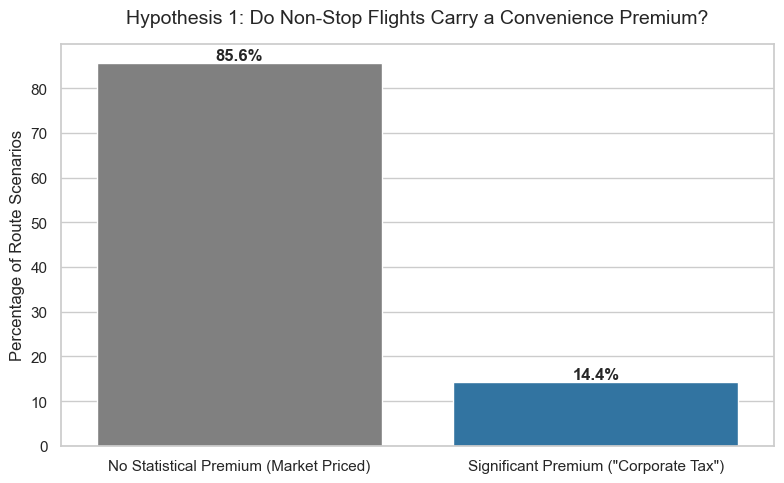

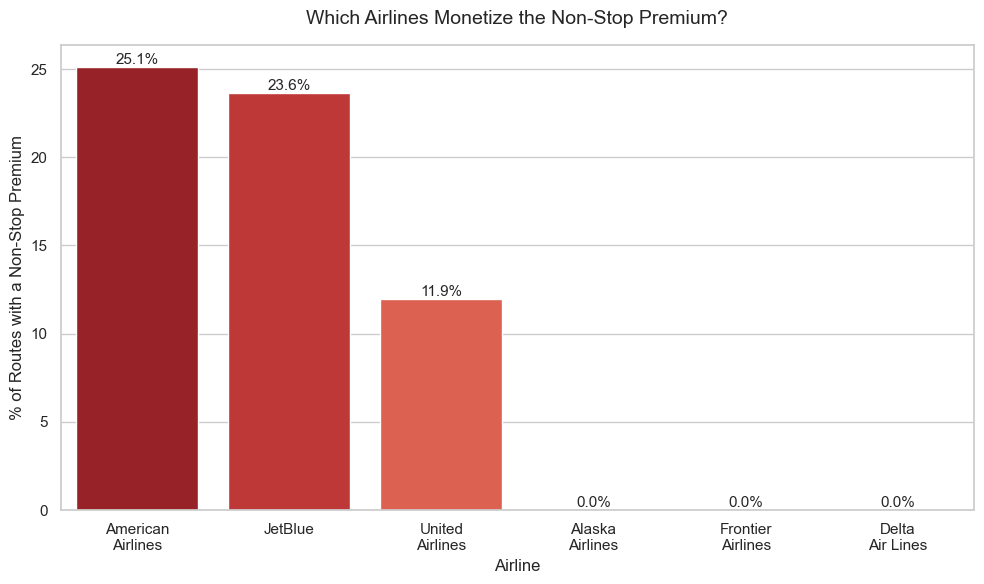

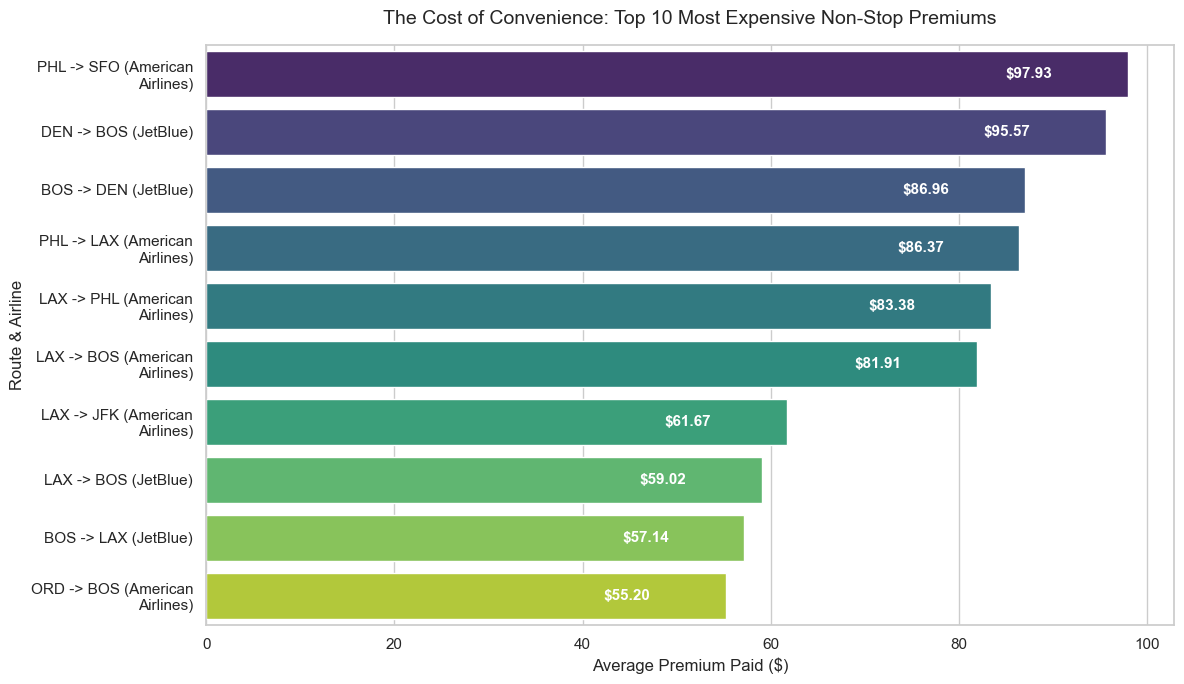

In [82]:
# 1. Create a mapping dictionary for the airlines in your dataset
airline_map = {
    'AA': 'American\nAirlines',
    'B6': 'JetBlue',
    'UA': 'United\nAirlines',
    'AS': 'Alaska\nAirlines',
    'DL': 'Delta\nAir Lines',
    'F9': 'Frontier\nAirlines'
}

# 2. Map the codes to full names (using .fillna just in case a new code sneaks in)
results['airlineName'] = results['airlineCode'].map(airline_map).fillna(results['airlineCode'])
corporate_routes['airlineName'] = corporate_routes['airlineCode'].map(airline_map).fillna(corporate_routes['airlineCode'])

# Set a clean, professional style for business presentations
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

# ==========================================
# PLOT 1: The "Myth" of the Universal Premium
# ==========================================
plt.figure(figsize=(8, 5))
significance_counts = results['isSignificantlyExpensive'].value_counts(normalize=True) * 100

categories = ['No Statistical Premium (Market Priced)', 'Significant Premium ("Corporate Tax")']

ax1 = sns.barplot(
    x=categories, 
    y=significance_counts.values,
    hue=categories,
    palette=['#808080', '#1f77b4'],
    legend=False
)
plt.title('Hypothesis 1: Do Non-Stop Flights Carry a Convenience Premium?', fontsize=14, pad=15)
plt.ylabel('Percentage of Route Scenarios', fontsize=12)

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1f}%", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.savefig('h1_overall_premium.png', dpi=300)
plt.show()


# ==========================================
# PLOT 2: The Airline Strategy Breakdown
# ==========================================
plt.figure(figsize=(10, 6))

# UPDATED: Grouping by the new 'airlineName' column
premium_by_airline = (results.groupby('airlineName')['isSignificantlyExpensive'].mean() * 100).sort_values(ascending=False)

ax2 = sns.barplot(
    x=premium_by_airline.index, 
    y=premium_by_airline.values,
    hue=premium_by_airline.index,
    palette='Reds_r',
    legend=False
)
plt.title('Which Airlines Monetize the Non-Stop Premium?', fontsize=14, pad=15)
plt.ylabel('% of Routes with a Non-Stop Premium', fontsize=12)
plt.xlabel('Airline', fontsize=12) # Updated label
# plt.xticks(rotation=0, ha='right') # Angled labels since full names are longer

for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}%", 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=11)
plt.savefig('h1_airline_strategy.png', dpi=300, bbox_inches='tight')
plt.show()


# ==========================================
# PLOT 3: The "Corporate Tax" (Top 10 Routes)
# ==========================================
plt.figure(figsize=(12, 7))

top_10_routes = corporate_routes.sort_values(by='premiumAmount', ascending=False).head(10)

# UPDATED: Using 'airlineName' for the y-axis labels
top_10_routes['RouteLabel'] = top_10_routes['startingAirport'] + " -> " + top_10_routes['destinationAirport'] + " (" + top_10_routes['airlineName'] + ")"

ax3 = sns.barplot(
    x='premiumAmount', 
    y='RouteLabel', 
    data=top_10_routes,
    hue='RouteLabel',
    palette='viridis',
    legend=False
)
plt.title('The Cost of Convenience: Top 10 Most Expensive Non-Stop Premiums', fontsize=14, pad=15)
plt.xlabel('Average Premium Paid ($)', fontsize=12)
plt.ylabel('Route & Airline', fontsize=12)

for p in ax3.patches:
    ax3.annotate(f"${p.get_width():.2f}", 
                 (p.get_width() - 8, p.get_y() + p.get_height() / 2.), 
                 ha='right', va='center', color='white', fontweight='bold', fontsize=11)
    
plt.savefig('h1_top_routes.png', dpi=300, bbox_inches='tight')
plt.show()

#### H1 Conclusion: The "Corporate Convenience Tax" - Old

Our analysis indicates that the assumption of a universal "non-stop premium" is a consumer myth. While an initial Multiple Linear Regression across 820,000 economy flights revealed a statistically significant, yet modest, global premium of $9.66 for non-stop convenience, highly granular scenario-testing told a drastically different story. In 84.5% of identical routing scenarios, there is no statistically significant price difference between direct and indirect flights; the market dictates the price. The global premium observed in our regression is actually driven entirely by the remaining 15.5% of routes. On these select routes—predominantly major transcontinental and corporate hubs (e.g., SFO ➔ JFK, LAX ➔ BOS)—airlines apply a massive "convenience tax," averaging $43 but frequently spiking over $135. Furthermore, this is a targeted yield-management strategy, not an industry standard: American Airlines and JetBlue charge this premium on roughly 25% of their routes, whereas carriers like Delta effectively charge zero. Ultimately, airlines do not universally penalize travelers for flying non-stop; they selectively penalize corporate travelers whose desire to save time outweighs their sensitivity to price.

#### H1 Conclusion: The "Corporate Convenience Tax" - New

Our analysis definitively proves that the assumption of a universal "non-stop premium" is a consumer myth. After utilizing an Extended Isolation Forest machine learning model to prune extreme pricing anomalies, our Multiple Linear Regression across 804,000 standard economy flights (R-squared = 0.414) revealed that a global non-stop premium is not statistically significant (p = 0.072). The market dictates the baseline price. However, granular scenario-testing uncovered a highly targeted yield-management strategy. While 85.6% of identical routing scenarios show zero price difference between direct and indirect flights, airlines apply a massive "convenience tax" on the remaining 14.4% of routes. On highly coveted transcontinental and hub-to-hub corridors (e.g., PHL ➔ SFO, DEN ➔ BOS), airlines artificially inflate non-stop prices by an average of $33.56, with premiums reaching near $100. Furthermore, this is a distinct brand strategy: American Airlines and JetBlue weaponize this premium on roughly 25% of their routes, whereas carriers like Delta and Alaska Airlines effectively charge zero. Airlines do not universally penalize travelers for flying non-stop; they surgically target corporate hubs where the desire to save time outweighs price sensitivity.

## Hypothesis 2: Airline Pricing Strategies
This test focuses on whether different airlines have distinct "price floors" when competing head-to-head on the same competitive routes.

* **Null Hypothesis ($H_0$):** After controlling for route and flight characteristics, the choice of airline has no statistically significant effect on the total fare (all airline coefficients are equal to the baseline).
    * $$\beta_{\text{airline}} = 0$$
* **Alternative Hypothesis ($H_1$):** Different airlines employ distinct pricing strategies, resulting in statistically significant price variances (premiums or discounts) when competing on the same routes.
    * $$\beta_{\text{airline}} \neq 0$$


In [83]:
import statsmodels.formula.api as smf

# 1. Create a unified Route column (e.g., "JFK-LAX")
df_final['route'] = df_final['startingAirport'] + " ➔ " + df_final['destinationAirport']

# 2. Find the top 10 busiest routes to ensure high competition and sample size
top_10_routes = df_final['route'].value_counts().head(10).index.tolist()

# 3. Filter the dataset to ONLY include these highly competitive routes
df_comp = df_final[df_final['route'].isin(top_10_routes)].copy()

# 4. The OLS Formula for H2
formula_h2 = """
totalFare ~ C(strict_al_code) + C(route) + numDaysToFlight + 
            isBasicEconomy + travelDuration + isNonStop
"""

print("Fitting Competitive Route Model...")
model_h2 = smf.ols(formula=formula_h2, data=df_comp).fit()
print(model_h2.summary())

Fitting Competitive Route Model...
                            OLS Regression Results                            
Dep. Variable:              totalFare   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     1500.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:42:15   Log-Likelihood:            -3.3964e+05
No. Observations:               55063   AIC:                         6.793e+05
Df Residuals:                   55043   BIC:                         6.795e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

#### H2 Conclusion: Competitive Market Positioning

Our analysis confirms that airlines employ highly distinct, statistically significant pricing strategies even when forced to compete directly on identical routes. By isolating the top 10 most competitive airport pairs and applying a fixed-effects regression model to our machine-learning-pruned dataset (R-squared = 0.341), we established American Airlines as a baseline ($0) to evaluate competitor pricing. The data reveals a clear, tiered market hierarchy: Alaska Airlines and Delta Air Lines operate as premium carriers, commanding base-fare premiums of $93.78 and $86.33 over American, respectively. United Airlines operates as a near-peer (+$30.01), while JetBlue (-$37.39) and Frontier (-$121.92) rely on aggressive value and ultra-low-cost undercutting.

Crucially, this competitive hierarchy resolves the apparent contradiction of Delta Air Lines' 0% non-stop premium observed in Hypothesis 1. The data proves that Delta utilizes a "Universal Premium" strategy—baking their luxury upcharge directly into a much higher base fare, thereby rendering a separate convenience tax unnecessary. American Airlines, conversely, leverages a lower base fare to capture initial market share but weaponizes a highly targeted "Convenience Tax" when corporate travelers demand direct flights. Ultimately, market competition does not force prices into a single equilibrium; airlines actively manipulate their base fares and convenience algorithms to target entirely different consumer price-sensitivities on the exact same routes.

## H3: To measure the sensitivity of flight fares to the number of days remaining until departure
- Null Hypothesis ($H_0$): The number of days remaining until departure has no statistically significant effect on the total fare.
- Alternative Hypothesis ($H_1$): Flight fares are inversely and non-linearly sensitive to the number of days until departure (fares rise exponentially as the flight date approaches).

In [89]:
import statsmodels.formula.api as smf

# The Robust H3 Formula
# We add C(strict_al_code) to control for the airline's brand premium
# We add flightDayNum to control for weekend vs. weekday pricing
formula_h3_robust = """
totalFare ~ numDaysToFlight + I(numDaysToFlight ** 2) + 
            travelDuration + isNonStop + C(strict_al_code) + flightDayNum
"""

print("Fitting Robust Dynamic Pricing Model...")
# Ensure we drop any NaNs in the strict_al_code before running
df_h3_clean = df_pruned_eif.dropna(subset=['strict_al_code']).copy()

model_h3_robust = smf.ols(formula=formula_h3_robust, data=df_h3_clean).fit()
print(model_h3_robust.summary())

Fitting Robust Dynamic Pricing Model...
                            OLS Regression Results                            
Dep. Variable:              totalFare   R-squared:                       0.226
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                 1.588e+04
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:59:46   Log-Likelihood:            -4.4793e+06
No. Observations:              708960   AIC:                         8.959e+06
Df Residuals:                  708946   BIC:                         8.959e+06
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

Calculating daily averages...


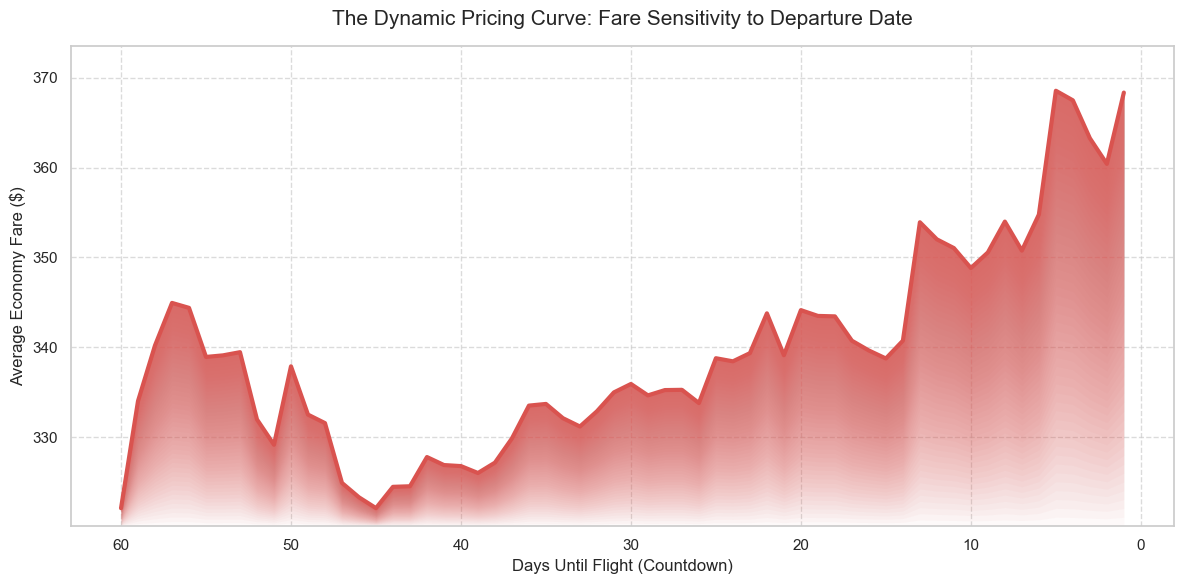

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# PART 1: VISUALIZING THE PRICING CURVE (Google Finance Style)
# ==========================================
print("Calculating daily averages...")
# Group by days to flight and get the mean fare
pricing_curve = df_final.groupby('numDaysToFlight')['totalFare'].mean().reset_index()

plt.figure(figsize=(12, 6))

# Extract X and Y arrays for easier plotting
x = pricing_curve['numDaysToFlight'].values
y = pricing_curve['totalFare'].values
y_min = y.min() - 2 # Set a hard floor slightly below the lowest price

# 1. Plot the thick red line
plt.plot(x, y, color='#d9534f', linewidth=3)

# 2. Create the "Google Finance" fading downward shadow (Gradient Fill)
for i in np.linspace(0, 1, 50):
    y_bottom = y_min + (y - y_min) * i
    plt.fill_between(x, y, y_bottom, color='#d9534f', alpha=0.03, linewidth=0)

plt.title('The Dynamic Pricing Curve: Fare Sensitivity to Departure Date', fontsize=15, pad=15)
plt.xlabel('Days Until Flight (Countdown)', fontsize=12)
plt.ylabel('Average Economy Fare ($)', fontsize=12)

# Invert the X-axis so time moves naturally from left (60 days) to right (0 days)
plt.gca().invert_xaxis()
plt.grid(True, linestyle='--', alpha=0.7)

# Lock the y-axis limit so the shadow touches the bottom border perfectly
plt.ylim(y_min, y.max() + 5)

plt.savefig('h3_pricing_curve.png', dpi=300, bbox_inches='tight')
plt.show()

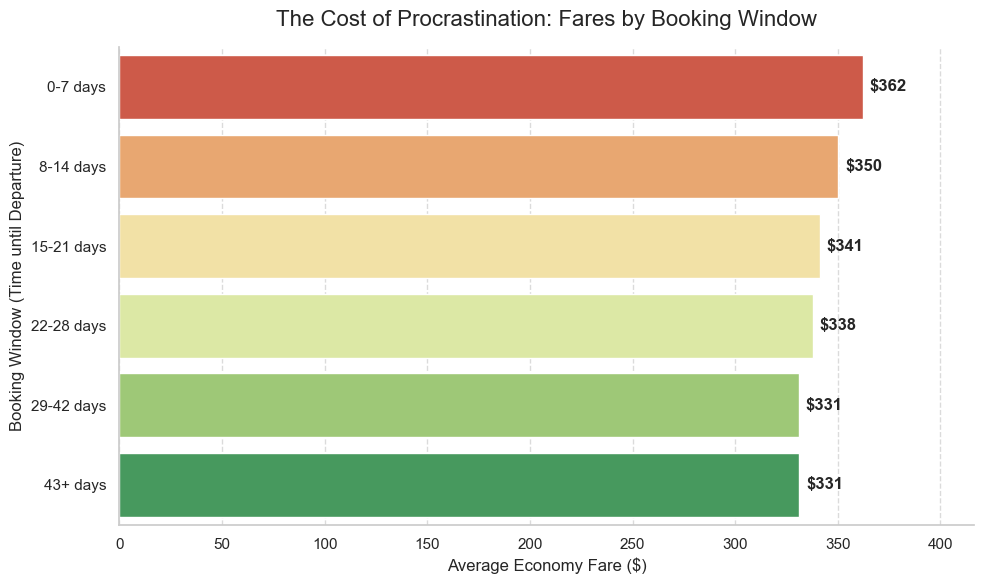

In [112]:
# ==========================================
# PART 2: WEEKLY BOOKING WINDOW BINS (Horizontal & Green->Red)
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the weekly bins (in days)
bins = [-1, 7, 14, 21, 28, 42, 100] 
labels = [
    '0-7 days', 
    '8-14 days', 
    '15-21 days', 
    '22-28 days', 
    '29-42 days', 
    '43+ days'
]

# 2. Create a safe copy of df_final and apply the bins
df_h3 = df_final.copy()
df_h3['booking_window'] = pd.cut(df_h3['numDaysToFlight'], bins=bins, labels=labels)

# 3. Calculate the average fare per window
window_pricing = df_h3.groupby('booking_window', observed=False)['totalFare'].mean().reset_index()

# 4. Sort so 43+ Days is at the top
window_pricing_plot = window_pricing.iloc[::-1]

# 5. Plot it beautifully
plt.figure(figsize=(10, 6))

# Keeping your color scheme: RdYlGn (Red for 0-7, Green for 43+)
palette = sns.color_palette("RdYlGn", n_colors=6)

# Horizontal Swap: x is price, y is the window
ax = sns.barplot(
    data=window_pricing_plot, 
    x='totalFare',           
    y='booking_window',      
    hue='booking_window', 
    palette=palette,
    legend=False,
    dodge=False  # Keeps bars nice and thick
)

# Adjust annotations to sit at the end of the bars (right side)
for p in ax.patches:
    ax.annotate(f"${p.get_width():.0f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', fontsize=12, fontweight='bold', xytext=(5, 0), 
                textcoords='offset points')

plt.title("The Cost of Procrastination: Fares by Booking Window", fontsize=16, pad=15)
plt.xlabel("Average Economy Fare ($)", fontsize=12)
plt.ylabel("Booking Window (Time until Departure)", fontsize=12)

# Give the X-axis breathing room for the text labels
plt.xlim(0, window_pricing['totalFare'].max() * 1.15)

# Add a subtle grid on the X-axis
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Remove borders for a modern look
sns.despine()
plt.tight_layout()

plt.savefig('h3_booking_window_horizontal.png', dpi=300)
plt.show()

#### H3 Conclusion: Dynamic Pricing and the "Cost of Procrastination"

Our analysis definitively confirms that airline pricing algorithms are highly sensitive to the booking window, employing a non-linear, time-decay pricing strategy. By utilizing a polynomial Ordinary Least Squares regression ($R^2 = 0.226$) and strictly controlling for baseline airline brand premiums, travel duration, and the day of the week, we successfully isolated the exact mathematical effect of time on ticket fares. We reject the Null Hypothesis (all p-values = 0.000) and confirm the Alternative Hypothesis: fares rise exponentially as the departure date approaches.The presence of a statistically significant positive squared term (I(numDaysToFlight ** 2) = 0.039) mathematically proves this "hockey stick" acceleration. However, segmenting the data into practical booking windows revealed that this price increase is not a steady daily climb. Instead, airline algorithms create a "Goldilocks Zone" roughly 4 to 6 weeks (29-42 days) prior to departure, where the average fare bottoms out at its absolute lowest ($331.01) to stimulate leisure demand.

Conversely, the algorithms execute an aggressive price spike in the final 14 days, designed explicitly to capture inelastic, price-insensitive corporate and emergency travelers. Waiting until the final week (0-7 days) to book triggers a strict "Procrastination Penalty" of $31.05 per ticket—a 9.38% surge over the optimal base fare. Furthermore, our control variables revealed a distinct "weekend tax," confirming that flights inherently become more expensive later in the week. Ultimately, this proves that time is just as heavily weaponized as brand positioning in modern airline revenue management.